# Competition Model: Fitting to Experimental Data

**Model:** Two proteins (A, B) competing for a limiting nuclear import factor

## Model Schematic

![Competition Model](diagram/competition_model.png)

The diagram shows protein A cycling between cytoplasmic free form ($A_f$), factor-bound complex ($AF$), and nuclear form ($A_n$). Protein B (not shown) follows identical kinetics. Both proteins compete for the limited factor F, creating competitive inhibition for nuclear import.

## Mathematical Derivation

### Model Description

We consider two proteins, A and B, that compete for a limiting assembly factor F that facilitates their nuclear import:

1. **Binding:** Both proteins bind the assembly factor in the cytoplasm with equal affinity
2. **Nuclear import:** Only protein-factor complexes are imported into the nucleus, at equal rates
3. **Factor recycling:** Upon import, the factor is released
4. **Differential degradation:** Proteins degrade in both compartments, with potentially different rates for A and B
5. **Protection:** When bound to the factor, proteins are protected from degradation
6. **Synthesis:** Both proteins are synthesised at the same constant rate

### Species

**Cytoplasm:** $A_f$, $B_f$, $F_f$ (free proteins/factor), $AF$, $BF$ (complexes)

**Nucleus:** $A_n$, $B_n$ (nuclear proteins)

### Reactions

**Binding equilibria and nuclear import:**

$$
\begin{aligned}
A_f + F_f &\xrightleftharpoons[k_{\text{off}}]{k_{\text{on}}} AF \xrightarrow{k_{\text{import}}} A_n + F_f \\
B_f + F_f &\xrightleftharpoons[k_{\text{off}}]{k_{\text{on}}} BF \xrightarrow{k_{\text{import}}} B_n + F_f
\end{aligned}
$$

**Degradation:**

$$
\begin{aligned}
A_f &\xrightarrow{\delta_f^A} \emptyset , \quad
B_f \xrightarrow{\delta_f^B} \emptyset \\
A_n &\xrightarrow{\delta_n^A} \emptyset ,  \quad
B_n \xrightarrow{\delta_n^B} \emptyset 
\end{aligned}
$$

**Synthesis:**

$$
\emptyset \xrightarrow{k_s} A_f, \quad \emptyset \xrightarrow{k_s} B_f
$$

### Quasi-Steady State Approximation

The ODE governing the complex $AF$ is

$$
\frac{d(AF)}{dt} = k_{\text{on}} A_f F_f - (k_{\text{off}} + k_{\text{import}}) AF
$$

Under the quasi-steady-state assumption, $k_{\text{on}}, (k_{\text{off}} + k_{\text{import}}) \gg k_s, \delta_f^A, \delta_f^B$, this simplifies to

$$
AF = \frac{A_fF_f}{K_M}, \quad BF = \frac{B_fF_f}{K_M}
$$

where

$$
K_M = \frac{k_{\text{off}} + k_{\text{import}}}{k_{\text{on}}}
$$

is the Michaelis constant.

### Conservation of Factor

$$
F_{\text{total}} = F_f + AF + BF = F_f\left(1 + \frac{A_f + B_f}{K_M}\right)
$$

Therefore:

$$
F_f = \frac{F_{\text{total}}}{1 + (A_f + B_f)/K_M} = \frac{F_{\text{total}}K_M}{K_M + A_f + B_f}
$$

### Simplified ODEs

The system reduces to:

$$
\begin{aligned}
\frac{dA_f}{dt} &= k_s - \frac{k_{\text{import}} F_{\text{total}} A_f}{K_M + A_f + B_f} - \delta_f^A A_f \\
\frac{dB_f}{dt} &= k_s - \frac{k_{\text{import}} F_{\text{total}} B_f}{K_M + A_f + B_f} - \delta_f^B B_f \\
\frac{dA_n}{dt} &= \frac{k_{\text{import}} F_{\text{total}} A_f}{K_M + A_f + B_f} - \delta_n^A A_n \\
\frac{dB_n}{dt} &= \frac{k_{\text{import}} F_{\text{total}} B_f}{K_M + A_f + B_f} - \delta_n^B B_n
\end{aligned}
$$

This is a **competitive import system** where A and B compete for the limited factor F.

### Parameterization for Fitting

**Free parameters (6):**
- $k_s$ (synthesis rate)
- $k_{\text{import}}$ (import rate)
- $F_{\text{total}}$ (total factor)
- $K_M$ (Michaelis constant)
- $\delta_f^A$ (cytoplasmic degradation of A)
- $\delta_n^B(\mathrm{degron})$ (auxin degradation increment; added to both $\delta_f^B$ and $\delta_n^B$)

**Fixed parameters (from experimental measurements):**
- $\delta_n^A$ (nuclear removal rate for RFP) from bleach chase experiments (VEH treatment)
- $\delta_n^B = f_B \cdot \delta_n^A$ where $f_B = $ RFP/GFP normalization ratio (from steady-state)

**Auxin perturbation:** additive in *both* compartments, $\delta_n^B \to \delta_n^B + \delta_n^B(\mathrm{degron})$ and $\delta_f^B \to \delta_f^B + \delta_n^B(\mathrm{degron})$, with $\delta_n^B(\mathrm{degron})$ fitted (also $\delta_f^B = \delta_f^A$ in the control condition)

**Experimental conditions:**
- **VEH_AUX (Inhibitor):** Start at control steady state, increase B degradation
- **AUX_VEH (Washout):** Start at perturbed steady state, decrease B degradation back to control

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize, differential_evolution
import warnings

from models import (
    integrate_competition_to_steady_state,
    simulate_competition_trajectory,
)
from utils import (
    save_parameters,
    load_experimental_data,
    calculate_time_averages,
    plot_data_preview,
)

warnings.filterwarnings("ignore")

# Data directory (all input CSVs)
DATA_DIR = Path("../data")

# Random seed for reproducible fitting
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting style
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11})

## Load Experimental Data

Loaded data for conditions: ['VEH_AUX', 'AUX_VEH']

Data points per condition:
  VEH_AUX: 24 time points
  AUX_VEH: 24 time points


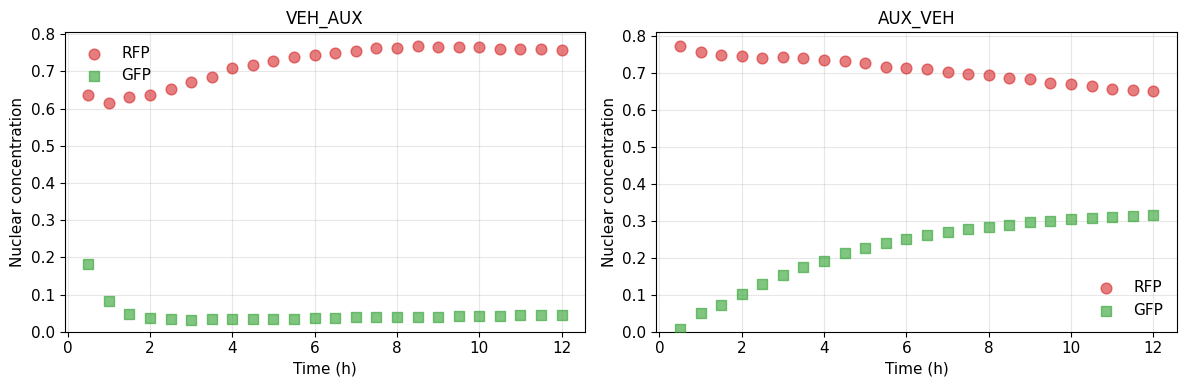

In [16]:
# Data normalization factors (from steady-state measurements)
RFP_NORMALIZATION = 0.5994
GFP_NORMALIZATION = 0.4153

# Load and normalize data
data_path = DATA_DIR / "mACmCh_LiveCellWashout_Values_ByExperiment.csv"
data = load_experimental_data(
    data_path, {"RFP": RFP_NORMALIZATION, "GFP": GFP_NORMALIZATION}
)

# Calculate time-averaged data for fitting
fit_conditions = ["VEH_AUX", "AUX_VEH"]
data_averaged = calculate_time_averages(data, fit_conditions)

# Use only first 12 hours for fitting
FIT_MAX_HOURS = 12.0
for code in fit_conditions:
    data_averaged[code] = data_averaged[code][
        data_averaged[code]["time"] <= FIT_MAX_HOURS
    ]

print(f"Loaded data for conditions: {list(data_averaged.keys())}")
print(f"\nData points per condition:")
for code, df in data_averaged.items():
    print(f"  {code}: {len(df)} time points")

# Preview the data
plot_data_preview(data_averaged, fit_conditions)

## Fixed Parameters from Experimental Measurements

In [17]:
# Load bleach chase data to get removal rate
bleach_chase_path = DATA_DIR / "mACmCh_BleachChase_ByExperiment.csv"
bleach_chase_df = pd.read_csv(bleach_chase_path, index_col=0)

# Calculate DELTA_N_A as mean RemovalRate_perhr for VEH treatment
veh_data = bleach_chase_df[bleach_chase_df["Treatment"] == "VEH"]
DELTA_N_A = veh_data["RemovalRate_perhr"].mean()

# Other fixed parameters
DELTA_N_B_FACTOR = RFP_NORMALIZATION / GFP_NORMALIZATION  # From steady-state ratio
DELTA_N_B = DELTA_N_B_FACTOR * DELTA_N_A  # Basal nuclear removal rate for B
# delta_n_B_degron: auxin increment, fit per model (added to both delta_f_B and delta_n_B)

print("Fixed parameters:")
print(
    f"  δ_n^A (RFP nuclear) = {DELTA_N_A:.4f} hr⁻¹ (from bleach chase data, n={len(veh_data)})"
)
print(f"  δ_n^B factor = {DELTA_N_B_FACTOR:.4f}")
print(f"  δ_n^B (control) = {DELTA_N_B:.4f} hr⁻¹")

Fixed parameters:
  δ_n^A (RFP nuclear) = 0.1352 hr⁻¹ (from bleach chase data, n=3)
  δ_n^B factor = 1.4433
  δ_n^B (control) = 0.1952 hr⁻¹


## Define Fitting Objective

In [18]:
RFP_WEIGHT = 1
EARLY_GFP_WEIGHT = 4


def objective_function(theta, data_averaged, return_predictions=False):
    """
    Objective function for parameter fitting.

    Parameters
    ----------
    theta : array-like
        [k_s, k_import, delta_f_A, delta_n_B_degron]
    K_M : float
        Michaelis constant, held fixed
    data_averaged : dict
        Experimental data for each condition
    return_predictions : bool
        If True, return (loss, predictions) instead of just loss
    """
    k_s, k_import, K_M, delta_f_A, delta_n_B_degron = theta

    # Parameter bounds check
    if any(x <= 0 for x in theta):
        return 1e10 if not return_predictions else (1e10, None)

    params = {
        "k_s": k_s,
        "k_import": k_import,
        "F_total": 1.0,  # k_import * F_total = Vmax so can just set F_total = 1.0 here
        "K_M": K_M,
        "delta_f_A": delta_f_A,
        "delta_n_B_factor": DELTA_N_B_FACTOR,
    }

    # Calculate degradation rates
    delta_n_A = DELTA_N_A
    delta_n_B_control = DELTA_N_B
    delta_n_B_perturbed = DELTA_N_B + delta_n_B_degron
    delta_f_B_control = delta_f_A
    delta_f_B_perturbed = delta_f_A + delta_n_B_degron

    # Calculate steady states
    try:
        ss_control = integrate_competition_to_steady_state(
            params, delta_f_B_control, delta_n_A, delta_n_B_control
        )
        ss_perturbed = integrate_competition_to_steady_state(
            params, delta_f_B_perturbed, delta_n_A, delta_n_B_perturbed
        )
    except:
        return 1e10 if not return_predictions else (1e10, None)

    # Simulate conditions
    conditions = {
        "VEH_AUX": (ss_control, delta_f_B_perturbed, delta_n_B_perturbed),
        "AUX_VEH": (ss_perturbed, delta_f_B_control, delta_n_B_control),
    }

    loss = 0.0
    predictions = {}

    for code, (y0, delta_f_B, delta_n_B) in conditions.items():
        if code not in data_averaged:
            continue

        data = data_averaged[code]
        t_max = data["time"].max()

        try:
            traj, times = simulate_competition_trajectory(
                params, delta_f_B, delta_n_A, delta_n_B, t_max, y0, n_points=100
            )
        except:
            return 1e10 if not return_predictions else (1e10, None)

        # Interpolate to data time points
        A_n_interp = np.interp(data["time"], times, traj[2])
        B_n_interp = np.interp(data["time"], times, traj[3])

        # Per-point GFP weights: emphasise the early decay that constrains the degron
        gfp_weights = np.ones(len(data))
        if code == "VEH_AUX":
            gfp_weights[data["time"].to_numpy() <= 2.0] = EARLY_GFP_WEIGHT

        rfp_error = np.sum((A_n_interp - data["rfp"]) ** 2)
        gfp_error = np.sum(gfp_weights * (B_n_interp - data["gfp"]) ** 2)

        if code == "VEH_AUX":
            rfp_error *= RFP_WEIGHT

        loss += rfp_error + gfp_error

        if return_predictions:
            predictions[code] = {
                "time": times,
                "A_n": traj[2],
                "B_n": traj[3],
                "A_n_interp": A_n_interp,
                "B_n_interp": B_n_interp,
            }

    if return_predictions:
        return loss, predictions
    return loss

## Run Optimization

In [19]:
# Parameter bounds
bounds = [
    (0.01, 1.0),  # k_s
    (0.1, 10.0),  # k_import
    (1e-4, 1.0),  # K_M
    (0.01, 1.0),  # delta_f_A
    (0.1, 5.0),  # delta_n_B_degron
]

print("Running global optimization...")
result_global = differential_evolution(
    objective_function,
    bounds,
    args=(data_averaged,),
    maxiter=500,
    popsize=15,
    seed=RANDOM_SEED,
    workers=1,
    updating="deferred",
)

print("\nRefining with local optimization...")
result_local = minimize(
    objective_function,
    result_global.x,
    args=(data_averaged,),
    method="L-BFGS-B",
    bounds=bounds,
)

best_params_array = result_local.x
best_loss = result_local.fun

print("\n" + "=" * 60)
print("OPTIMIZATION COMPLETE")
print("=" * 60)
print(f"Final loss: {best_loss:.4e}")
print(f"\nBest-fit parameters:")
print(f"  k_s       = {best_params_array[0]:.4f} hr⁻¹")
print(f"  k_import  = {best_params_array[1]:.4f} hr⁻¹")
print(f"  F_total   = 1.0")
print(f"  K_M       = {best_params_array[2]:.6f}")
print(f"  delta_f_A = {best_params_array[3]:.4f} hr⁻¹")
print(f"  delta_n_B_degron = {best_params_array[4]:.4f} hr⁻¹")

Running global optimization...

Refining with local optimization...

OPTIMIZATION COMPLETE
Final loss: 3.1080e-02

Best-fit parameters:
  k_s       = 0.1553 hr⁻¹
  k_import  = 0.1892 hr⁻¹
  F_total   = 1.0
  K_M       = 0.151009
  delta_f_A = 0.1632 hr⁻¹
  delta_n_B_degron = 1.5531 hr⁻¹


## Save Parameters

In [20]:
# Package parameters for saving
best_params = {
    "k_s": best_params_array[0],
    "k_import": best_params_array[1],
    "F_total": 1.0,
    "K_M": best_params_array[2],
    "delta_f_A": best_params_array[3],
    "delta_n_B_degron": best_params_array[4],
    "delta_n_A": DELTA_N_A,
    "delta_n_B_factor": DELTA_N_B_FACTOR,
    "delta_n_B": DELTA_N_B,
}

# Save to JSON
output_path = Path("fitted_parameters/competition_params.json")
save_parameters(best_params, output_path)
print(f"\nSaved parameters to: {output_path.resolve()}")


Saved parameters to: /Users/z3532965/src/publications/2026_POLR2A_homeostasis/Modelling/abundance_homeostasis/fitted_parameters/competition_params.json


## Visualise Fits

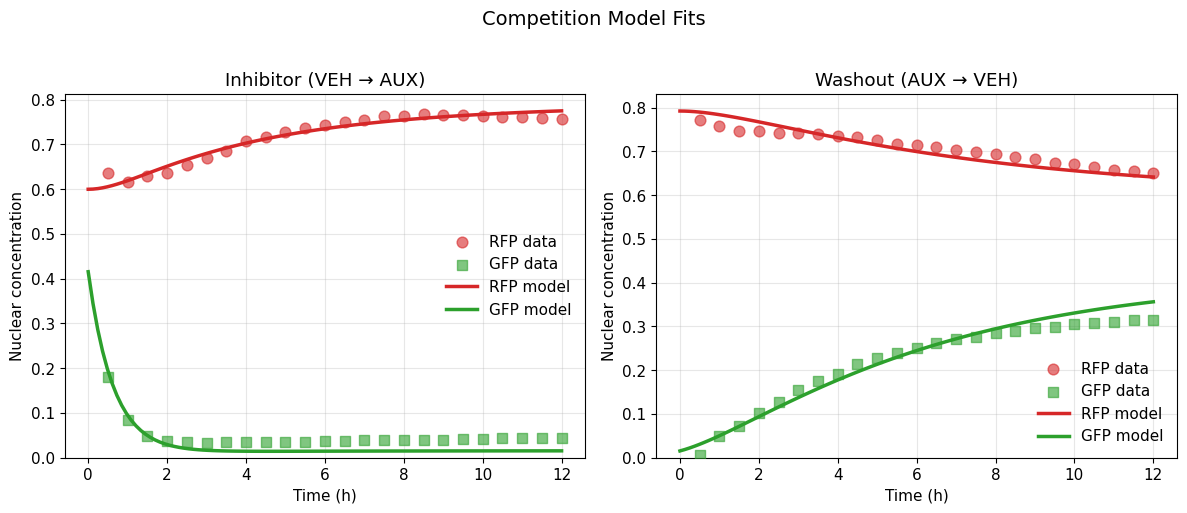

In [21]:
# Get predictions with best parameters
_, predictions = objective_function(
    best_params_array, data_averaged, return_predictions=True
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {"rfp": "#d62728", "gfp": "#2ca02c"}
titles = {"VEH_AUX": "Inhibitor (VEH → AUX)", "AUX_VEH": "Washout (AUX → VEH)"}

for ax, code in zip(axes, ["VEH_AUX", "AUX_VEH"]):
    data = data_averaged[code]
    pred = predictions[code]

    # Plot data
    ax.scatter(
        data["time"],
        data["rfp"],
        color=colors["rfp"],
        alpha=0.6,
        s=60,
        label="RFP data",
        zorder=3,
    )
    ax.scatter(
        data["time"],
        data["gfp"],
        color=colors["gfp"],
        alpha=0.6,
        s=60,
        marker="s",
        label="GFP data",
        zorder=3,
    )

    # Plot model
    ax.plot(
        pred["time"], pred["A_n"], color=colors["rfp"], linewidth=2.5, label="RFP model"
    )
    ax.plot(
        pred["time"], pred["B_n"], color=colors["gfp"], linewidth=2.5, label="GFP model"
    )

    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Nuclear concentration")
    ax.set_title(titles[code])
    ax.legend(frameon=False)
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.3)

fig.suptitle("Competition Model Fits", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("competition_model_fits.pdf", bbox_inches="tight")
plt.show()